# Retail Demand Forecasting & Sales Analysis

## Objective
This project analyzes daily retail sales and inventory data across multiple stores, categories, and regions to uncover business insights using a structured EDA framework (OPTD: Overview, Pain Point, Trend, Deets, Recommend), and to build and compare two forecasting approaches — a classical ARIMA model and an LSTM neural network — for predicting future product demand.

## Dataset
Source: [Kaggle — Retail Store Inventory Forecasting Dataset](insert link)
~73,000+ rows of daily records across multiple stores and products, including sales, inventory levels, pricing, weather, promotions, and holidays.

## Tools
- **Python (Pandas, Matplotlib/Seaborn/Plotly)** — data cleaning and exploratory analysis
- **Statsmodels (ARIMA)** and **TensorFlow/Keras (LSTM)** — time series forecasting
- **Power BI** — dashboard visualization
- **GitHub** — version control and portfolio hosting

## Notebook structure
This project is split into two notebooks:
1. `01_Data_Cleaning_and_EDA.ipynb` (this notebook) — cleaning and full OPTD exploratory analysis
2. `02_Forecasting.ipynb` — ARIMA baseline vs. LSTM model comparison

## Framework
Analysis follows the OPTD(R) framework:
- **Overview** — what's the general picture?
- **Pain Point** — where are problems concentrated?
- **Trend** — when does it happen, who's affected, has it happened before?
- **Deets** — root-cause cross-checks
- **Recommend** — suggested next steps, not firm conclusions

## Phase 1: Setup

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates

## 2. Initial Inspection

In [46]:
# Reading from our "cloud storage" (Google Drive)
file_path = '/content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis/data/raw/retail_store_inventory.csv'
df = pd.read_csv(file_path)

## 3. Initial Inspection
# Checking shape, column dtypes, and a sample of rows to identify dates, categoricals, and numerics
print("Dataset Shape:", df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

Dataset Shape: (73100, 15)

--- Data Types ---
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

--- First 5 Rows ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer



--- Summary Statistics ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
count,73100,73100,73100,73100,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100,73100.000000,73100.000000,73100
unique,731,5,20,5,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4
top,2024-01-01,S001,P0001,Furniture,East,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,Spring
freq,100,14620,3655,14699,18349,NaN,NaN,NaN,NaN,NaN,NaN,18290,NaN,NaN,18317
mean,NaN,NaN,NaN,NaN,NaN,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,NaN,0.497305,55.146077,NaN
std,NaN,NaN,NaN,NaN,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,NaN,0.499996,26.191408,NaN
min,NaN,NaN,NaN,NaN,NaN,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,NaN,0.000000,5.030000,NaN
25%,NaN,NaN,NaN,NaN,NaN,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,NaN,0.000000,32.680000,NaN
50%,NaN,NaN,NaN,NaN,NaN,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,NaN,0.000000,55.010000,NaN
75%,NaN,NaN,NaN,NaN,NaN,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,NaN,1.000000,77.820000,NaN


## 3. Cleaning: Missing Values & Duplicates

In [50]:
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Exact Duplicates ---")
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Remove duplicates if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicate_count} duplicate rows. New shape: {df.shape}")

--- Missing Values ---
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

--- Exact Duplicates ---
Duplicate rows: 0


## 4. Cleaning: Data Type Fixes

In [48]:
# Convert Date to proper datetime
df['Date'] = pd.to_datetime(df['Date'])

print("Updated Date dtype:", df['Date'].dtype)

Updated Date dtype: datetime64[ns]


## 5. Cleaning: Categoricals & Outliers

In [49]:
print("--- Categorical Unique Values ---")
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality', 'Holiday/Promotion']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

print("\n--- Outlier/Impossible Value Check ---")
print("Negative Inventory:", (df['Inventory Level'] < 0).sum())
print("Negative Units Sold:", (df['Units Sold'] < 0).sum())
print("Negative Demand Forecast:", (df['Demand Forecast'] < 0).sum())
print("Zero or Negative Price:", (df['Price'] <= 0).sum())

--- Categorical Unique Values ---
Category: ['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']
Region: ['North' 'South' 'West' 'East']
Weather Condition: ['Rainy' 'Sunny' 'Cloudy' 'Snowy']
Seasonality: ['Autumn' 'Summer' 'Winter' 'Spring']
Holiday/Promotion: [0 1]

--- Outlier/Impossible Value Check ---
Negative Inventory: 0
Negative Units Sold: 0
Negative Demand Forecast: 673
Zero or Negative Price: 0


## 6. Cleaning: Handle Outliers & Export

In [57]:
# Filter out rows with negative demand forecasts
df_clean = df[df['Demand Forecast'] >= 0].copy()

# Define your actual Drive project path
project_path = '/content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis'
cleaned_dir = f'{project_path}/data/cleaned'

# Ensure the folder exists in your Drive
os.makedirs(cleaned_dir, exist_ok=True)

# Export cleaned dataset permanently
export_path = f'{cleaned_dir}/cleaned_retail_data.csv'
df_clean.to_csv(export_path, index=False)

print(f"Cleaned dataset safely exported to: {export_path}")

Cleaned dataset safely exported to: /content/drive/MyDrive/Retail-Demand-Forecasting-Sales-Analysis/data/cleaned/cleaned_retail_data.csv


## Phase 2. EDA: Overview (O - Overview)

**Business Question:** What are our baseline KPIs for the dataset?

In [58]:
# Print baseline metrics instead of charting them
avg_units = df_clean['Units Sold'].mean()
avg_inventory = df_clean['Inventory Level'].mean()
price_min = df_clean['Price'].min()
price_max = df_clean['Price'].max()

print("--- Baseline KPIs ---")
print(f"Average Units Sold: {avg_units:.2f}")
print(f"Average Inventory Level: {avg_inventory:.2f}")
print(f"Price Range: ${price_min:.2f} to ${price_max:.2f}")

--- Baseline KPIs ---
Average Units Sold: 137.71
Average Inventory Level: 275.17
Price Range: $10.00 to $100.00


**Takeaway:** I can see our baseline averages sit at roughly 138 units sold per transaction against an inventory level of 275. Our pricing is strictly bound between 10.00 and 100.00 dollars.

**Business Question:** What does the total sales volume look like over time? Is the overall trend flat, growing, or seasonal?

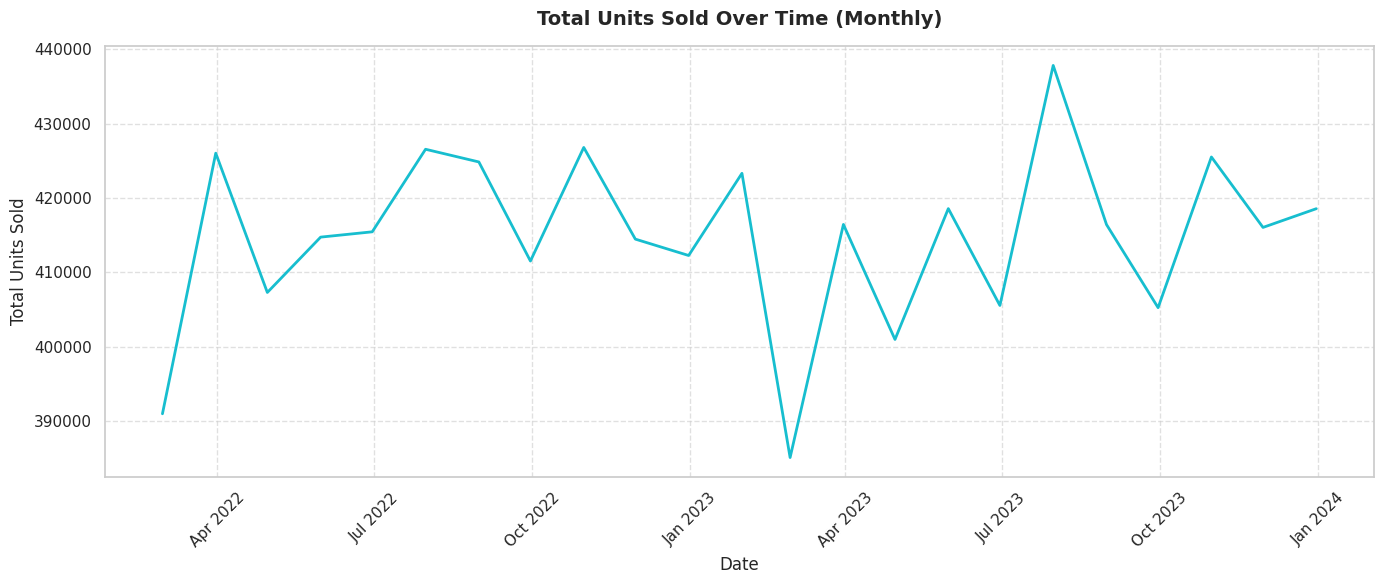

In [64]:
# Resample to monthly total units sold to avoid noisy daily plotting
df_time = df_clean.set_index('Date')
monthly_sales = df_time['Units Sold'].resample('ME').sum().reset_index()

monthly_sales = monthly_sales.iloc[1:-1]

plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=monthly_sales,
    x='Date',
    y='Units Sold',
    color='#17becf',
    linewidth=2
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.title('Total Units Sold Over Time (Monthly)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Takeaway:** Looking at the monthly sales from 2022 to early 2024, I don't see a steady, long-term growth trend. The volume is volatile, mostly hovering between 410k and 420k units, with a sharp dip in early 2023 and a massive spike later that summer.

## Phase 2. EDA: Pain Point (P)

**Business Question:** Which Category and Region combinations suffer from the highest stockout rates?

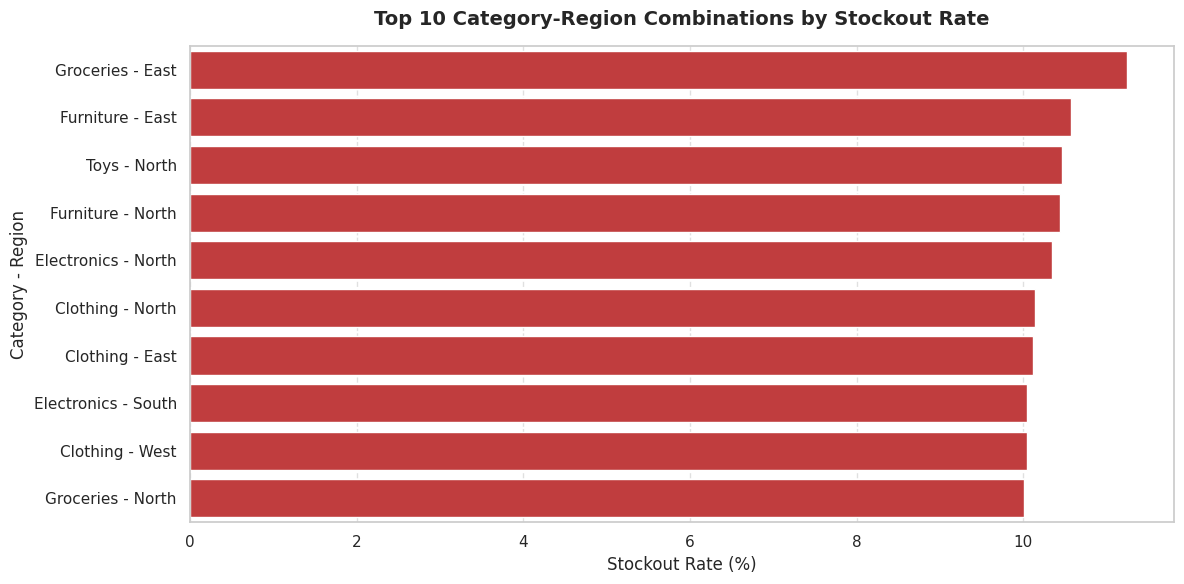

In [65]:
# Calculate sell-through rate to evaluate inventory efficiency
df_clean['Sell_Through_Rate'] = df_clean['Units Sold'] / df_clean['Inventory Level']

# Define category-specific thresholds (top 10% = stockout risk, bottom 10% = overstock risk)
high_thresh = df_clean.groupby('Category')['Sell_Through_Rate'].transform(lambda x: x.quantile(0.90))
low_thresh = df_clean.groupby('Category')['Sell_Through_Rate'].transform(lambda x: x.quantile(0.10))

# Flag rows based on their specific category's distribution
df_clean['Is_Stockout'] = df_clean['Sell_Through_Rate'] >= high_thresh
df_clean['Is_Overstock'] = df_clean['Sell_Through_Rate'] <= low_thresh

# Calculate rates per Category & Region
combo_rates = df_clean.groupby(['Category', 'Region'])[['Is_Stockout', 'Is_Overstock']].mean().reset_index()
combo_rates['Combo'] = combo_rates['Category'] + " - " + combo_rates['Region']
combo_rates['Stockout_Rate_%'] = combo_rates['Is_Stockout'] * 100

# Sort for the worst 10 stockout rates to rank the underperformers
top_stockouts = combo_rates.sort_values('Stockout_Rate_%', ascending=False).head(10)

# Plot the pain points
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_stockouts,
    x='Stockout_Rate_%',
    y='Combo',
    color='#d62728'
)

plt.title('Top 10 Category-Region Combinations by Stockout Rate', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Stockout Rate (%)', fontsize=12)
plt.ylabel('Category - Region', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Takeaway:** Groceries in the East region have the highest stockout rate, peaking over 11%. Think of this like a prep station constantly running out of key ingredients mid-service—the inventory replenishments in the East and North regions just aren't keeping up with the actual order volume, especially for bulkier or perishable goods.

**Business Question:** Are specific stores consistently underperforming, and where are they located?

--- Store ID Sanity Check ---
Minimum transactions for a single store: 14477
Maximum transactions for a single store: 14500


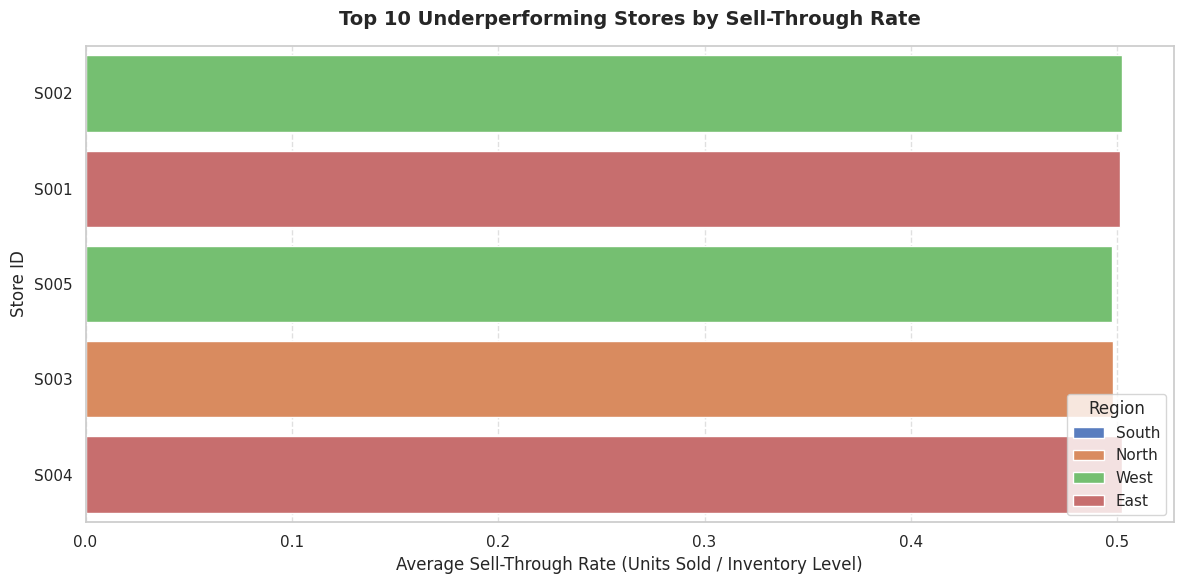

In [66]:
# Sanity check: confirm Store IDs have enough transactions to represent a real store, not just a data artifact
store_counts = df_clean['Store ID'].value_counts()
print("--- Store ID Sanity Check ---")
print(f"Minimum transactions for a single store: {store_counts.min()}")
print(f"Maximum transactions for a single store: {store_counts.max()}")

# Calculate the average sell-through rate per store to find the worst performers
store_performance = df_clean.groupby(['Store ID', 'Region'])['Sell_Through_Rate'].mean().reset_index()

# Sort ascending to grab the bottom 10 stores (lowest sell-through means highest underperformance)
bottom_stores = store_performance.sort_values('Sell_Through_Rate', ascending=True).head(10)

# Plot the underperforming stores
plt.figure(figsize=(12, 6))
sns.barplot(
    data=bottom_stores,
    x='Sell_Through_Rate',
    y='Store ID',
    hue='Region',
    dodge=False,
    palette='muted'
)

plt.title('Top 10 Underperforming Stores by Sell-Through Rate', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Sell-Through Rate (Units Sold / Inventory Level)', fontsize=12)
plt.ylabel('Store ID', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Region', loc='lower right')
plt.tight_layout()
plt.show()

**Takeaway:** There are actually only 5 unique stores in the entire dataset, and all of them are hovering right around a 50% sell-through rate. Performance is completely flat across the board—no single store is backing up the line or burning ingredients more than the others.

## Phase 2. EDA: Trend (T)

**Business Question:** Do sales volumes follow a predictable pattern based on the day of the week or the month of the year?

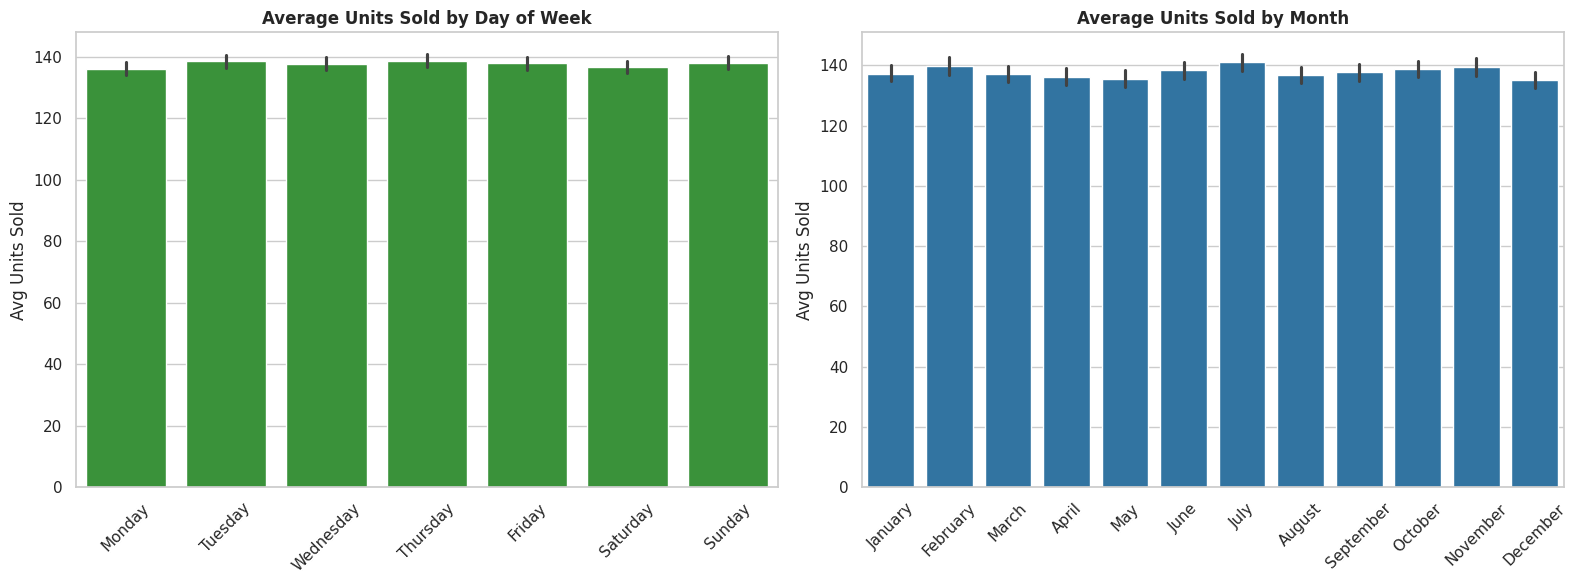

In [67]:
# Extract time components for grouping
df_clean['Day_of_Week'] = df_clean['Date'].dt.day_name()
df_clean['Month'] = df_clean['Date'].dt.month_name()

# Order the categories logically for the charts
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Set up a side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Day of Week (using mean to see average daily performance)
sns.barplot(
    ax=axes[0],
    data=df_clean,
    x='Day_of_Week',
    y='Units Sold',
    order=dow_order,
    color='#2ca02c',
    errorbar=('ci', 95) # Built-in 95% confidence interval
)
axes[0].set_title('Average Units Sold by Day of Week', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Avg Units Sold')
axes[0].set_xlabel('')

# Plot 2: Month
sns.barplot(
    ax=axes[1],
    data=df_clean,
    x='Month',
    y='Units Sold',
    order=month_order,
    color='#1f77b4',
    errorbar=('ci', 95)
)
axes[1].set_title('Average Units Sold by Month', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Avg Units Sold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

**Takeaway:** The error bars overlap heavily across every day of the week and every month. There is no real seasonality or predictable time-based pattern driving sales volume here; demand remains functionally constant.

**Business Question:** How much do external factors like Weather Conditions and Holiday/Promotions actually drive sales?

/tmp/ipykernel_1737/2025595295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1737/2025595295.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


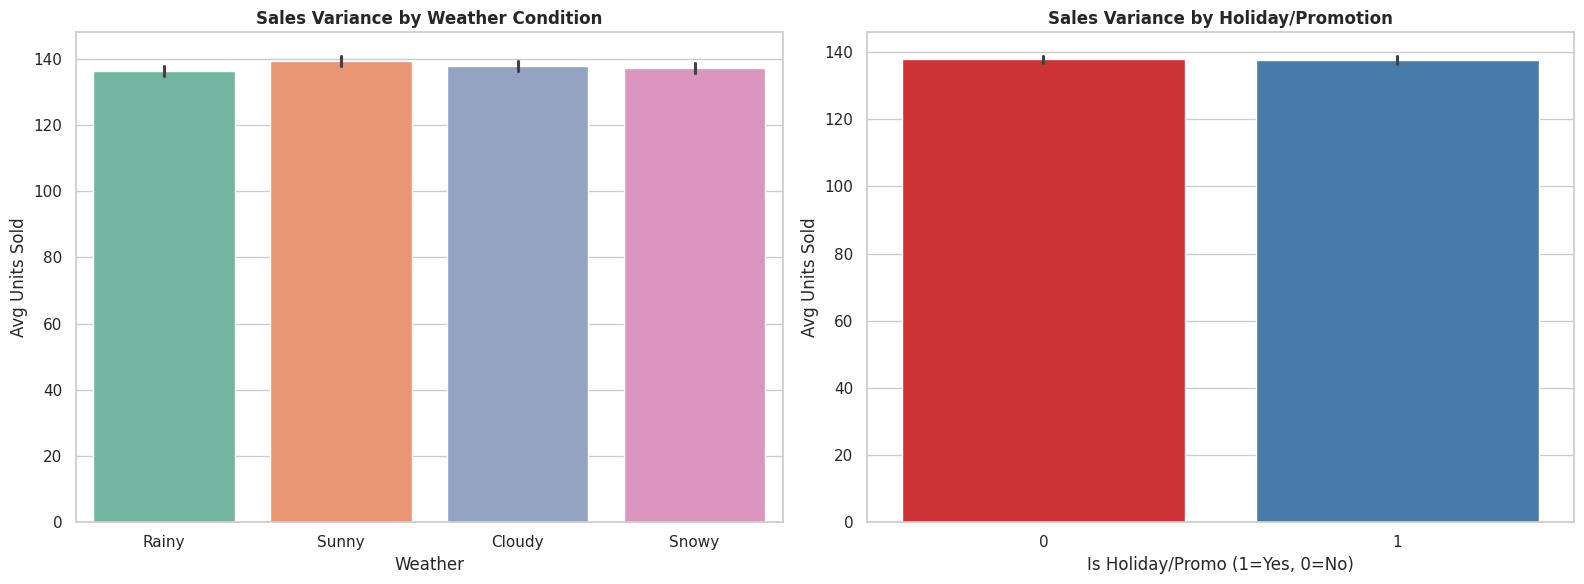

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Weather Conditions
sns.barplot(
    ax=axes[0],
    data=df_clean,
    x='Weather Condition',
    y='Units Sold',
    palette='Set2',
    errorbar=('ci', 95)
)
axes[0].set_title('Sales Variance by Weather Condition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Units Sold')
axes[0].set_xlabel('Weather')

# Plot 2: Promotions
sns.barplot(
    ax=axes[1],
    data=df_clean,
    x='Holiday/Promotion',
    y='Units Sold',
    palette='Set1',
    errorbar=('ci', 95)
)
axes[1].set_title('Sales Variance by Holiday/Promotion', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')
axes[1].set_xlabel('Is Holiday/Promo (1=Yes, 0=No)')

plt.tight_layout()
plt.show()

**Takeaway:** Checking the confidence intervals shows they overlap perfectly across all weather conditions and promotion statuses. Neither external weather events nor marketing promotions actually drive a statistically meaningful variance in sales.

## 5. EDA: Deets (D)

**Business Question:** Are our sales constrained by our inventory levels? (e.g., Are we selling less simply because we don't have enough stock on hand?)

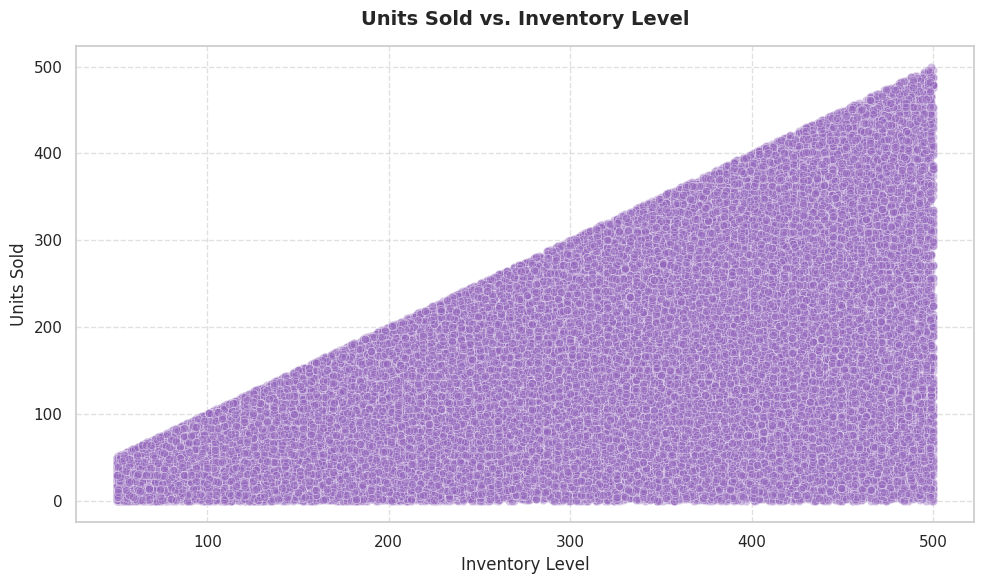

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='Inventory Level',
    y='Units Sold',
    alpha=0.4,
    color='#9467bd'
)

plt.title('Units Sold vs. Inventory Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Inventory Level', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Takeaway:** The plot forms a perfect triangle. Units sold never exceed the inventory level, which acts as a hard physical cap. However, below that cap, the distribution is completely random. Having more inventory does not inherently drive higher demand; it simply raises the ceiling on what is possible to sell.

## 6. EDA: Recommend (R)

**Business Question:** Based on the EDA, what actions should we suggest to stakeholders?

**Takeaways:**
*   **Investigate the East Region's Groceries:** This combination has the highest stockout rate (over 11%). I suggest reviewing their replenishment schedules, as they are routinely running out of stock mid-service.
*   **Don't over-index on weather or promotions:** The data shows zero statistically meaningful variance in sales across different weather conditions or promotional periods. I suggest pausing heavy promotional spending until we can track a campaign that actually moves the needle.
*   **Acknowledge the data limitations:** The sales volume is remarkably flat across all stores, months, and days. The lack of organic variance suggests this dataset might be heavily synthesized. Any predictive modeling moving forward should set baseline expectations accordingly, as finding real signal in this noise will be difficult.